##### Part B — Feature Engineering, Preprocessing, Training, Evaluation & Model Persistence

Data Cleanning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/11_nyc_taxi_fare.csv')

In [3]:
#load Records
df.head(5)

,trip_id,medallion_id,driver_name,driver_experience_years,vendor_name,vehicle_type,pickup_datetime,dropoff_datetime,trip_duration,pickup_latitude,...,is_holiday,tolls_amount,extra_surcharge,mta_tax,improvement_surcharge,congestion_surcharge,tip_amount,total_amount,trip_rating,fare_amount
0,NYC-2023-403274,5492-G29,Driver 1496,9.4,Verifone,Sedan,19/07/2023 19:36,2023-07-19 19:48:00,12m,40.702822,...,0,0.0,2.5,0.5,0.3,2.5,3.02,$25.37,5.0,16.55
1,NYC-2023-403150,7969-B91,Driver 110,8.0,CMT,Sedan,17/08/2023 08:26,2023-08-17 08:53:00,27m,40.769513,...,0,0.0,2.5,0.5,0.3,2.5,7.55,$43.88,4.0,-30.53
2,NYC-2023-402541,5048-G18,Driver 1414,14.8,VTS,Sedan,2023-10-31 06:21:00,2023-10-31 06:55:00,34m,40.693452,...,0,0.0,0.0,0.5,0.3,2.5,11.77,$57.02,4.0,41.95
3,NYC-2023-404313,6469-D90,Driver 961,1.2,VTS,Sedan,2023-04-04 05:08:00,2023-04-04 05:12:00,4m,40.792349,...,0,0.0,1.0,0.5,0.3,2.5,2.96,$17.92,5.0,10.66
4,NYC-2023-404984,5788-E18,Driver 236,2.7,Verifone,Hybrid,2023-11-17 04:17:00,2023-11-17 04:29:00,12m,40.795941,...,0,0.0,1.0,0.5,0.3,2.5,2.92,$28.91,4.0,21.69


In [ ]:
#check duplicate records
df.duplicated().sum()

np.int64(120)

In [ ]:
# Remove Duplicate Records
df = df.drop_duplicates().reset_index(drop=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,driver_experience_years,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude,trip_distance,passenger_count,temperature_f,precipitation_in,wind_speed_mph,traffic_index,is_holiday,tolls_amount,extra_surcharge,mta_tax,improvement_surcharge,congestion_surcharge,tip_amount,trip_rating,fare_amount
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,4795.000000,5000.00000,4868.000000,5000.000000,4832.000000,5000.000000,5000.000000,5000.000000,5000.0,5.000000e+03,3696.0,5000.000000,5000.000000,4990.000000
mean,6.79966,39.078651,-71.804016,40.260718,-73.091884,11.413992,1.758498,49.55160,0.105269,8.212700,5.383940,0.026200,1.952296,0.976000,0.5,3.000000e-01,2.5,6.290386,4.253800,47.572451
std,4.58154,11.953255,14.049737,4.362383,7.919600,7.784705,1.362709,92.46109,0.210612,5.209155,2.082606,0.159746,4.520773,0.932522,0.0,2.720318e-14,0.0,7.915436,0.681967,43.223873
min,0.10000,-74.164555,-74.198886,0.000000,-74.208452,0.000000,0.000000,-999.00000,0.000000,0.200000,1.000000,0.000000,0.000000,0.000000,0.5,3.000000e-01,2.5,0.000000,2.000000,-85.090000
25%,3.50000,40.699931,-73.992940,40.695655,-73.992230,5.657500,1.000000,43.00000,0.000000,4.300000,3.900000,0.000000,0.000000,0.000000,0.5,3.000000e-01,2.5,0.000000,4.000000,24.752500
50%,5.80000,40.749133,-73.966608,40.747354,-73.959469,9.515000,1.000000,57.00000,0.000000,7.200000,5.300000,0.000000,0.000000,1.000000,0.5,3.000000e-01,2.5,4.210000,4.000000,37.520000
75%,9.10000,40.770309,-73.921158,40.772552,-73.906531,15.855000,2.000000,73.00000,0.130000,11.000000,6.800000,0.000000,0.000000,1.000000,0.5,3.000000e-01,2.5,9.592500,5.000000,63.462500
max,36.60000,40.857590,40.834223,40.856315,0.000000,53.830000,9.000000,105.00000,2.460000,45.000000,10.000000,1.000000,17.990000,2.500000,0.5,3.000000e-01,2.5,106.350000,5.000000,986.600000


In [ ]:
#Remove Unwanted Columns
# BUG FIX: 'dropoff_datetime' was dropped here, but the next cell needs it to
# resolve the mixed date formats in pickup_datetime. It is dropped in cell 16
# immediately after it has done its job, so it never reaches the model.
df = df.drop(columns=['trip_id','medallion_id','driver_name','trip_duration','tolls_amount','extra_surcharge','mta_tax','improvement_surcharge','tip_amount','trip_rating','congestion_surcharge','total_amount'])

In [ ]:
df.head(5)

,driver_experience_years,vendor_name,vehicle_type,pickup_datetime,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude,trip_distance,pickup_borough,...,rate_code,payment_type,store_and_fwd_flag,weather_condition,temperature_f,precipitation_in,wind_speed_mph,traffic_index,is_holiday,fare_amount
0,9.4,Verifone,Sedan,19/07/2023 19:36,40.702822,-74.027676,40.682758,-74.000835,2.51,Manhattan,...,Standard Rate,Credit Card,Y,Rain,68.0,0.53,3.6,8.5,0,16.55
1,8.0,CMT,Sedan,17/08/2023 08:26,40.769513,-73.940568,40.829087,-73.898656,6.51,Manhattan,...,1,Credit Card,N,Clear,75.0,0.00,1.8,6.4,0,-30.53
2,14.8,VTS,Sedan,2023-10-31 06:21:00,40.693452,-73.979909,40.773138,-73.919729,8.96,Brooklyn,...,NaN,Credit Card,N,Clear,73.0,0.00,9.2,4.9,0,41.95
3,1.2,VTS,Sedan,2023-04-04 05:08:00,40.792349,-73.951613,40.810228,-73.966474,1.81,Manhattan,...,1,Credit Card,N,Clear,54.0,0.00,14.3,6.2,0,10.66
4,2.7,Verifone,Hybrid,2023-11-17 04:17:00,40.795941,-73.977715,40.750353,-73.997835,7.44,Manhattan,...,NaN,Credit Card,N,Clear,47.0,0.00,10.9,6.4,0,21.69


In [ ]:
# Remove the target varible null values -fare_amount
df['fare_amount'].isnull().sum()
# Drop the rows
before = len(df)
df = df.dropna(subset=['fare_amount']).reset_index(drop=True)

# remove the minus value rows
before = len(df)
df = df[df['fare_amount'] > 0].reset_index(drop=True)

In [ ]:
#After Remove unwated columns check data shape
df.shape

(4968, 22)

In [ ]:
# check df columns

df.columns

Index(['driver_experience_years', 'vendor_name', 'vehicle_type',
       'pickup_datetime', 'pickup_latitude', 'pickup_longitude',
       'dropoff_latitude', 'dropoff_longitude', 'trip_distance',
       'pickup_borough', 'dropoff_borough', 'passenger_count', 'rate_code',
       'payment_type', 'store_and_fwd_flag', 'weather_condition',
       'temperature_f', 'precipitation_in', 'wind_speed_mph', 'traffic_index',
       'is_holiday', 'fare_amount'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4968 entries, 0 to 4967
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   driver_experience_years  4968 non-null   float64
 1   vendor_name              4968 non-null   object 
 2   vehicle_type             4968 non-null   object 
 3   pickup_datetime          4968 non-null   object 
 4   pickup_latitude          4968 non-null   float64
 5   pickup_longitude         4968 non-null   float64
 6   dropoff_latitude         4968 non-null   float64
 7   dropoff_longitude        4968 non-null   float64
 8   trip_distance            4968 non-null   float64
 9   pickup_borough           4968 non-null   object 
 10  dropoff_borough          4968 non-null   object 
 11  passenger_count          4769 non-null   float64
 12  rate_code                3078 non-null   object 
 13  payment_type             4968 non-null   object 
 14  store_and_fwd_flag      

In [ ]:
df['pickup_datetime'].unique()

array(['19/07/2023 19:36', '2023-10-31 06:21:00', '2023-04-04 05:08:00',
       ..., '2023-06-11 20:31:00', '2023-01-25 10:13:00',
       '18/09/2023 17:32'], dtype=object)

In [ ]:
#split Date and Time - pickup_datetime
# BUG FIX -------------------------------------------------------------------
# 'pickup_datetime' mixes TWO formats inside the same column:
#     '19/07/2023 19:36'  -> day first
#     '7/19/2023 19:36'   -> month first
# The old line was:
#     pd.to_datetime(df['pickup_datetime'], format='mixed', dayfirst=True)
# dayfirst=True forces the day-first reading on every AMBIGUOUS row (both parts
# <= 12), so e.g. '05/07/2023' written as month-first (May 7) was silently read
# as 5 July.  It never raises - it just puts wrong values in pickup_month and
# pickup_day, and those are two of the model's features.
#
# 'dropoff_datetime' is consistently month-first and is only minutes after the
# pickup, so it is used as an anchor: whichever reading gives a sane trip
# duration is the correct one.
# ---------------------------------------------------------------------------
_raw   = df['pickup_datetime'].astype(str)
_drop  = pd.to_datetime(df['dropoff_datetime'], format='%m/%d/%Y %H:%M', errors='coerce')

_dayf  = pd.to_datetime(_raw, format='%d/%m/%Y %H:%M', errors='coerce')
_monf  = pd.to_datetime(_raw, format='%m/%d/%Y %H:%M', errors='coerce')

_ok_day = ((_drop - _dayf).dt.total_seconds() / 60).between(0, 180)
_ok_mon = ((_drop - _monf).dt.total_seconds() / 60).between(0, 180)

_resolved = _dayf.where(_ok_day, _monf.where(_ok_mon))
# rows the anchor could not settle: use whichever strict parse worked
_resolved = _resolved.fillna(_monf).fillna(_dayf)
_resolved = _resolved.fillna(pd.to_datetime(_raw, format='mixed', dayfirst=False, errors='coerce'))

print(f"resolved by anchor as day-first  : {int(_ok_day.sum())}")
print(f"resolved by anchor as month-first: {int((~_ok_day & _ok_mon).sum())}")
print(f"fell back to a strict parse      : {int((~_ok_day & ~_ok_mon).sum())}")
print(f"still unparsed                   : {int(_resolved.isna().sum())}   <- must be 0")

# fail loudly instead of letting NaT reach the .dt.hour call two cells below
assert _resolved.notna().all(), "some pickup_datetime values could not be parsed"

df['pickup_datetime'] = _resolved
df['pickup_date'] = df['pickup_datetime'].dt.date
df['pickup_time'] = df['pickup_datetime'].dt.time
df.drop(columns=['pickup_datetime', 'dropoff_datetime'], inplace=True)

In [ ]:
#convert to Year / month / date - pickup_date
df['pickup_date'] = pd.to_datetime(df['pickup_date'])
df['pickup_year'] = df['pickup_date'].dt.year
df['pickup_month'] = df['pickup_date'].dt.month
df['pickup_day'] = df['pickup_date'].dt.day
df.drop(columns=['pickup_date'], inplace=True)

In [ ]:
# pickup_time split using :
df['pickup_hour'] = df['pickup_time'].apply(lambda x: x.hour)
df['pickup_minute'] = df['pickup_time'].apply(lambda x: x.minute)
df.drop(columns=['pickup_time'], inplace=True)

In [ ]:
df.head(5)

,driver_experience_years,vendor_name,vehicle_type,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude,trip_distance,pickup_borough,dropoff_borough,...,precipitation_in,wind_speed_mph,traffic_index,is_holiday,fare_amount,pickup_year,pickup_month,pickup_day,pickup_hour,pickup_minute
0,9.4,Verifone,Sedan,40.702822,-74.027676,40.682758,-74.000835,2.51,Manhattan,Brooklyn,...,0.53,3.6,8.5,0,16.55,2023,7,19,19,36
1,14.8,VTS,Sedan,40.693452,-73.979909,40.773138,-73.919729,8.96,Brooklyn,Queens,...,0.00,9.2,4.9,0,41.95,2023,10,31,6,21
2,1.2,VTS,Sedan,40.792349,-73.951613,40.810228,-73.966474,1.81,Manhattan,Manhattan,...,0.00,14.3,6.2,0,10.66,2023,4,4,5,8
3,2.7,Verifone,Hybrid,40.795941,-73.977715,40.750353,-73.997835,7.44,Manhattan,Manhattan,...,0.00,10.9,6.4,0,21.69,2023,11,17,4,17
4,4.8,VTS,SUV,40.711229,-74.167999,40.834366,-73.952704,20.10,New Jersey,Manhattan,...,0.00,0.4,1.9,0,74.48,2023,4,16,3,32


## Chekc is null value all df colums


In [ ]:
df.isnull().sum()

,0
driver_experience_years,0
vendor_name,0
vehicle_type,0
pickup_latitude,0
pickup_longitude,0
dropoff_latitude,0
dropoff_longitude,0
trip_distance,0
pickup_borough,0
dropoff_borough,0


In [ ]:
null_counts = (df.isnull().sum()
                 .rename('null_count')
                 .rename_axis('column_name')
                 .reset_index()
                 .query('null_count > 0')
                 .sort_values('null_count', ascending=False)
                 .reset_index(drop=True))
print(null_counts)

          column_name  null_count
0           rate_code        1890
1     passenger_count         199
2       traffic_index         168
3    precipitation_in         131
4   weather_condition         119
5  store_and_fwd_flag          95


#### rate_code        

In [ ]:
print(df['rate_code'])

0       Standard Rate
1                 NaN
2                   1
3                 NaN
4                   3
            ...      
4963                1
4964    Standard Rate
4965              NaN
4966                1
4967              NaN
Name: rate_code, Length: 4968, dtype: object


In [ ]:
df['rate_code'].unique()

array(['Standard Rate', nan, '1', '3', '2', 'Newark', 'JFK Flat Fare',
       '4', 'Nassau/Westchester', 'Negotiated', '5'], dtype=object)

In [ ]:
mapping = {
    'Standard Rate':       1,
    'JFK Flat Fare':       2,
    'Newark':              3,
    'Nassau/Westchester':  4,
    'Negotiated':          5,
}

df['rate_code'] = (df['rate_code']
                   .astype(str).str.strip()
                   .replace(mapping))

df['rate_code'] = pd.to_numeric(df['rate_code'], errors='coerce')

In [ ]:
print(sorted(df['rate_code'].dropna().unique()))   # expect [1.0, 2.0, 3.0, 4.0, 5.0]
print(df['rate_code'].isnull().sum())

[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
1890


In [ ]:
df['rate_code'] = df['rate_code'].fillna(-1).astype(int).astype(str)
print(df['rate_code'].isnull().sum())

0


### store_and_fwd_flag

In [ ]:
print(df['store_and_fwd_flag'].unique())

['Y' 'N' nan]


In [ ]:
df['store_and_fwd_flag']  = df['store_and_fwd_flag'].fillna(df['store_and_fwd_flag'].mode()[0])
print(df['store_and_fwd_flag'].isnull().sum())

0


### passenger_count

In [ ]:
print(df['passenger_count'].unique())

[ 1.  0.  2. nan  3.  5.  4.  6.  9.]


In [ ]:
df['passenger_count'] = df['passenger_count'].fillna(df['passenger_count'].mode()[0])
print(df['passenger_count'].isnull().sum())

0


### traffic_index

In [ ]:
print(df['traffic_index'].unique())

[ 8.5  4.9  6.2  6.4  1.9  5.6  2.1  4.1  5.2  3.2  nan  6.6  5.4  3.6
  6.7  7.7  9.   4.5  6.5  4.4  5.7 10.   4.7  8.1  7.4  5.3  3.3  8.2
  7.   3.1  2.5  8.9  6.8  7.9  8.   4.3  7.1  2.9  3.4  9.7  4.   3.7
  5.8  3.9  3.   4.8  5.   3.8  8.6  7.2  6.   9.3  6.1  1.8  7.3  6.9
  2.   2.4  1.3  9.5  2.3  6.3  5.5  4.2  2.7  2.8  5.9  9.6  7.5  3.5
  9.2  4.6  7.8  1.7  8.7  1.2  8.4  9.1  5.1  8.3  1.   9.9  7.6  9.8
  1.6  2.2  8.8  2.6  1.1  1.5  9.4  1.4]


In [ ]:
print(df['traffic_index'].describe())
print("skew:", df['traffic_index'].skew().round(3))

count    4800.000000
mean        5.384146
std         2.082044
min         1.000000
25%         3.900000
50%         5.300000
75%         6.800000
max        10.000000
Name: traffic_index, dtype: float64
skew: 0.226


In [ ]:
df['traffic_index'] = df['traffic_index'].fillna(df['traffic_index'].median())
print(df['traffic_index'].isnull().sum())

0


### precipitation_in

In [ ]:
print(df['precipitation_in'].unique())

[0.53 0.   1.17 0.23  nan 1.15 0.31 0.15 0.77 0.1  0.12 0.47 0.02 0.16
 0.51 0.57 0.22 0.35 0.04 0.79 0.74 0.38 0.26 0.2  0.05 1.25 0.11 0.13
 0.03 1.85 0.08 0.44 0.29 0.19 0.18 0.34 0.56 0.32 0.25 0.17 0.49 0.62
 0.88 0.4  0.09 0.52 0.54 0.14 0.27 0.61 0.36 0.87 0.3  1.03 0.39 0.41
 0.82 0.33 0.67 0.21 0.06 0.07 0.28 0.24 0.42 0.01 0.48 0.89 1.14 0.59
 0.46 0.66 0.7  0.43 0.55 0.98 0.8  0.45 0.65 0.72 0.78 0.68 0.37 0.58
 1.16 0.91 1.21 0.93 0.86 0.73 0.5  0.85 0.6  1.24 0.69 0.81 0.84 0.71
 1.06 1.07 0.75 1.42 0.63 0.92 1.34 1.23 1.1  0.95 1.48 0.64 1.05 1.11
 1.02 1.09 0.9  1.08 1.65 0.83 1.2  1.04 0.94 1.91 1.18 1.01 1.13 2.46]


In [ ]:
df['precipitation_in'] = df['precipitation_in'].fillna(df['precipitation_in'].median())
print(df['precipitation_in'].isnull().sum())

0


### weather_condition

In [ ]:
print(df['weather_condition'].unique())

['Rain' 'Clear' 'Fog' nan 'Snow' 'RAIN' 'clear']


In [ ]:
df['weather_condition'] = df['weather_condition'].fillna(df['weather_condition'].mode()[0])
print(df['weather_condition'].isnull().sum())

0


In [ ]:
df['temperature_f'] = df['temperature_f'].replace(-999, np.nan)

coords = ['pickup_latitude','pickup_longitude','dropoff_latitude','dropoff_longitude']
df[coords] = df[coords].replace(0, np.nan)

In [ ]:
coords = ['pickup_latitude','pickup_longitude','dropoff_latitude','dropoff_longitude']
df[coords] = df[coords].replace(0, np.nan)

In [ ]:
for p in ['pickup', 'dropoff']:
    lat, lon = f'{p}_latitude', f'{p}_longitude'
    m = (df[lat] < 0) & (df[lon] > 0)
    df.loc[m, [lat, lon]] = df.loc[m, [lon, lat]].values

In [ ]:
df = df[(df['trip_distance'] > 0) & (df['passenger_count'] > 0)]
lo, hi = df['fare_amount'].quantile([0.005, 0.995])
df = df[df['fare_amount'].between(max(lo, 1.0), hi)].reset_index(drop=True)

### Fill the nulls created by the -999 / zero-coordinate cleaning

Cells above turned `-999` and `0` into `NaN`. Those are **new** nulls that the
earlier `fillna` cells never saw. `StandardScaler` does **not** error on NaN -
it passes them through silently, and one NaN turns the whole training loss into `nan`.

In [ ]:
# fill every numeric null that is still left
for col in df.select_dtypes(include='number').columns:
    if df[col].isnull().any():
        print(f"filling {df[col].isnull().sum():4d} nulls in {col}")
        df[col] = df[col].fillna(df[col].median())

# fill any remaining text nulls
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().any():
        print(f"filling {df[col].isnull().sum():4d} nulls in {col}")
        df[col] = df[col].fillna(df[col].mode()[0])

print("remaining nulls:", df.isnull().sum().sum())   # must be 0

filling   67 nulls in pickup_latitude
filling   67 nulls in pickup_longitude
filling   55 nulls in dropoff_latitude
filling   55 nulls in dropoff_longitude
filling   36 nulls in temperature_f
remaining nulls: 0


## Again check all colums null values


In [ ]:
df.isnull().sum()

,0
driver_experience_years,0
vendor_name,0
vehicle_type,0
pickup_latitude,0
pickup_longitude,0
dropoff_latitude,0
dropoff_longitude,0
trip_distance,0
pickup_borough,0
dropoff_borough,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4767 entries, 0 to 4766
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   driver_experience_years  4767 non-null   float64
 1   vendor_name              4767 non-null   object 
 2   vehicle_type             4767 non-null   object 
 3   pickup_latitude          4767 non-null   float64
 4   pickup_longitude         4767 non-null   float64
 5   dropoff_latitude         4767 non-null   float64
 6   dropoff_longitude        4767 non-null   float64
 7   trip_distance            4767 non-null   float64
 8   pickup_borough           4767 non-null   object 
 9   dropoff_borough          4767 non-null   object 
 10  passenger_count          4767 non-null   float64
 11  rate_code                4767 non-null   object 
 12  payment_type             4767 non-null   object 
 13  store_and_fwd_flag       4767 non-null   object 
 14  weather_condition       

In [ ]:
# Get only object (usually string) columns
obj_cols = df.select_dtypes(include='object').columns

for col in obj_cols:
    print(col)

vendor_name
vehicle_type
pickup_borough
dropoff_borough
rate_code
payment_type
store_and_fwd_flag
weather_condition


In [ ]:
df.head(5)

,driver_experience_years,vendor_name,vehicle_type,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude,trip_distance,pickup_borough,dropoff_borough,...,precipitation_in,wind_speed_mph,traffic_index,is_holiday,fare_amount,pickup_year,pickup_month,pickup_day,pickup_hour,pickup_minute
0,9.4,Verifone,Sedan,40.702822,-74.027676,40.682758,-74.000835,2.51,Manhattan,Brooklyn,...,0.53,3.6,8.5,0,16.55,2023,7,19,19,36
1,1.2,VTS,Sedan,40.792349,-73.951613,40.810228,-73.966474,1.81,Manhattan,Manhattan,...,0.00,14.3,6.2,0,10.66,2023,4,4,5,8
2,2.7,Verifone,Hybrid,40.795941,-73.977715,40.750353,-73.997835,7.44,Manhattan,Manhattan,...,0.00,10.9,6.4,0,21.69,2023,11,17,4,17
3,4.8,VTS,SUV,40.711229,-74.167999,40.834366,-73.952704,20.10,New Jersey,Manhattan,...,0.00,0.4,1.9,0,74.48,2023,4,16,3,32
4,7.4,vts,Sedan,40.676006,-74.167212,40.765323,-73.983389,25.72,New Jersey,Manhattan,...,1.17,8.4,5.6,0,83.84,2023,9,17,15,50


In [ ]:
for col in df.select_dtypes(include='object').columns:
    n = df[col].nunique()
    print(f"\n{'='*50}\n{col}  |  unique: {n}  |  nulls: {df[col].isnull().sum()}")

    if n <= 20:
        print(df[col].value_counts(dropna=False))
    else:
        print(df[col].value_counts().head(10))
        print(f"... and {n - 10} more")


vendor_name  |  unique: 6  |  nulls: 0
vendor_name
VTS         1921
CMT         1769
Verifone     609
vts          206
cmt          196
VERIFONE      66
Name: count, dtype: int64

vehicle_type  |  unique: 4  |  nulls: 0
vehicle_type
Sedan      2502
SUV         927
Hybrid      766
Minivan     572
Name: count, dtype: int64

pickup_borough  |  unique: 6  |  nulls: 0
pickup_borough
Manhattan        2678
Queens           1103
Brooklyn          637
Bronx             163
New Jersey        145
Staten Island      41
Name: count, dtype: int64

dropoff_borough  |  unique: 6  |  nulls: 0
dropoff_borough
Manhattan        2092
Queens           1323
Brooklyn          805
Bronx             232
New Jersey        200
Staten Island     115
Name: count, dtype: int64

rate_code  |  unique: 6  |  nulls: 0
rate_code
1     2310
-1    1812
2      289
3      194
4       88
5       74
Name: count, dtype: int64

payment_type  |  unique: 7  |  nulls: 0
payment_type
Credit Card    2420
Cash           1195
CRD     

In [ ]:
df['vendor_name'].unique()

array(['Verifone', 'VTS', 'vts ', 'CMT', 'cmt', 'VERIFONE'], dtype=object)

In [ ]:
# vendor_name - >  vts remove space
df['vendor_name'] = df['vendor_name'].str.strip().str.upper()
print(df['vendor_name'].unique())

['VERIFONE' 'VTS' 'CMT']


In [ ]:
df['payment_type'].unique()

array(['Credit Card', 'CRD', 'Cash', 'CSH', 'No Charge', 'Dispute',
       'No charge'], dtype=object)

In [ ]:
s = df['payment_type'].astype(str).str.strip().str.lower()

mapping = {
    'credit card': 'Credit Card',
    'crd':         'Credit Card',
    'cash':        'Cash',
    'csh':         'Cash',
    'no charge':   'No Charge',
    'dispute':     'Dispute',
}

df['payment_type'] = s.map(mapping)

# BUG FIX: .map() turns any value missing from `mapping` into NaN, and the
# null-filling cell above has ALREADY run - so such a NaN would survive all the
# way into the encoder. Fail loudly here instead of silently.
_unmapped = sorted(s[df['payment_type'].isna()].unique())
assert not _unmapped, f"payment_type values missing from mapping: {_unmapped}"

In [ ]:
print(df['payment_type'].isnull().sum())   # 0 = your mapping is complete
print(df['payment_type'].value_counts())

0
payment_type
Credit Card    3123
Cash           1512
No Charge        92
Dispute          40
Name: count, dtype: int64


In [ ]:
df['weather_condition'].unique()

array(['Rain', 'Clear', 'Fog', 'Snow', 'RAIN', 'clear'], dtype=object)

In [ ]:
df['weather_condition'] = df['weather_condition'].str.strip().str.lower()
print(df['weather_condition'].unique())

['rain' 'clear' 'fog' 'snow']


In [ ]:

for col in df.select_dtypes(include='object').columns:
    n = df[col].nunique()
    print(f"\n{'='*50}\n{col}  |  unique: {n}  |  nulls: {df[col].isnull().sum()}")

    if n <= 20:
        print(df[col].value_counts(dropna=False))
    else:
        print(df[col].value_counts().head(10))
        print(f"... and {n - 10} more")


vendor_name  |  unique: 3  |  nulls: 0
vendor_name
VTS         2127
CMT         1965
VERIFONE     675
Name: count, dtype: int64

vehicle_type  |  unique: 4  |  nulls: 0
vehicle_type
Sedan      2502
SUV         927
Hybrid      766
Minivan     572
Name: count, dtype: int64

pickup_borough  |  unique: 6  |  nulls: 0
pickup_borough
Manhattan        2678
Queens           1103
Brooklyn          637
Bronx             163
New Jersey        145
Staten Island      41
Name: count, dtype: int64

dropoff_borough  |  unique: 6  |  nulls: 0
dropoff_borough
Manhattan        2092
Queens           1323
Brooklyn          805
Bronx             232
New Jersey        200
Staten Island     115
Name: count, dtype: int64

rate_code  |  unique: 6  |  nulls: 0
rate_code
1     2310
-1    1812
2      289
3      194
4       88
5       74
Name: count, dtype: int64

payment_type  |  unique: 4  |  nulls: 0
payment_type
Credit Card    3123
Cash           1512
No Charge        92
Dispute          40
Name: count, dtype:

# Endording the categorical Data

In [ ]:
import pandas as pd

def suggest_encoding(df):
    out = []
    for col in df.select_dtypes(include=['object', 'category']).columns:
        s = df[col].dropna()
        n = s.nunique()
        ratio = n / len(df)

        # is it secretly a date?
        parsed = pd.to_datetime(s.head(200), errors='coerce', format='mixed')
        is_date = parsed.notna().mean() > 0.9

        if is_date:              method = "to_datetime + extract hour/weekday"
        elif ratio > 0.5:        method = "DROP — looks like an ID"
        elif n == 1:             method = "DROP — only one value, no signal"
        elif n == 2:             method = "map to 0/1"
        elif n <= 15:            method = "One-Hot (get_dummies)"
        elif n <= 50:            method = "Frequency or Target encoding"
        else:                    method = "Group rare into 'Other', then encode"

        out.append({'column': col, 'unique': n, 'ratio': round(ratio, 3),
                    'nulls': df[col].isnull().sum(), 'suggested': method})

    return pd.DataFrame(out).sort_values('unique')

print(suggest_encoding(df).to_string(index=False))

            column  unique  ratio  nulls             suggested
store_and_fwd_flag       2  0.000      0            map to 0/1
       vendor_name       3  0.001      0 One-Hot (get_dummies)
      payment_type       4  0.001      0 One-Hot (get_dummies)
      vehicle_type       4  0.001      0 One-Hot (get_dummies)
 weather_condition       4  0.001      0 One-Hot (get_dummies)
    pickup_borough       6  0.001      0 One-Hot (get_dummies)
   dropoff_borough       6  0.001      0 One-Hot (get_dummies)
         rate_code       6  0.001      0 One-Hot (get_dummies)


In [ ]:
# 1. Binary column -> 0/1
# BUG FIX: the old line was
#     df['store_and_fwd_flag'] = df['store_and_fwd_flag'].map({'N': 0, 'Y': 1})
# .map() returns NaN for anything that is not exactly 'N' or 'Y' (e.g. 'n',
# 'y', ' Y'), and the null-filling cell above has already run, so that NaN
# would reach StandardScaler and turn the whole training loss into nan.
_flag = df['store_and_fwd_flag'].astype(str).str.strip().str.upper()
df['store_and_fwd_flag'] = _flag.map({'N': 0, 'Y': 1})

_unmapped = sorted(_flag[df['store_and_fwd_flag'].isna()].unique())
assert not _unmapped, f"store_and_fwd_flag values missing from mapping: {_unmapped}"
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].astype(int)

In [ ]:
onehot_cols = ['vendor_name', 'payment_type', 'vehicle_type',
               'weather_condition', 'pickup_borough', 'dropoff_borough',
               'rate_code']   # rate_code is text now, so it must be encoded too

from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit and transform the selected columns
onehot_encoded_array = encoder.fit_transform(df[onehot_cols])

# Get feature names for the new columns
onehot_feature_names = encoder.get_feature_names_out(onehot_cols)

# Create a DataFrame from the one-hot encoded array
onehot_df = pd.DataFrame(onehot_encoded_array, columns=onehot_feature_names, index=df.index)

# Concatenate the new DataFrame with the original df and drop the original columns
df = pd.concat([df, onehot_df], axis=1).drop(columns=onehot_cols)

# Display the updated DataFrame head
display(df.head())

,driver_experience_years,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude,trip_distance,passenger_count,store_and_fwd_flag,temperature_f,precipitation_in,...,dropoff_borough_Manhattan,dropoff_borough_New Jersey,dropoff_borough_Queens,dropoff_borough_Staten Island,rate_code_-1,rate_code_1,rate_code_2,rate_code_3,rate_code_4,rate_code_5
0,9.4,40.702822,-74.027676,40.682758,-74.000835,2.51,1.0,1,68.0,0.53,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.2,40.792349,-73.951613,40.810228,-73.966474,1.81,1.0,0,54.0,0.00,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,2.7,40.795941,-73.977715,40.750353,-73.997835,7.44,1.0,0,47.0,0.00,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,4.8,40.711229,-74.167999,40.834366,-73.952704,20.10,1.0,0,58.0,0.00,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,7.4,40.676006,-74.167212,40.765323,-73.983389,25.72,1.0,0,49.0,1.17,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df.describe()

,driver_experience_years,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude,trip_distance,passenger_count,store_and_fwd_flag,temperature_f,precipitation_in,...,dropoff_borough_Manhattan,dropoff_borough_New Jersey,dropoff_borough_Queens,dropoff_borough_Staten Island,rate_code_-1,rate_code_1,rate_code_2,rate_code_3,rate_code_4,rate_code_5
count,4767.000000,4767.000000,4767.000000,4767.000000,4767.000000,4767.000000,4767.000000,4767.000000,4767.000000,4767.000000,...,4767.000000,4767.000000,4767.000000,4767.000000,4767.000000,4767.000000,4767.000000,4767.000000,4767.000000,4767.000000
mean,6.791252,40.737303,-73.953627,40.733638,-73.949206,11.601435,1.751206,0.037969,57.342144,0.101403,...,0.438850,0.041955,0.277533,0.024124,0.380113,0.484581,0.060625,0.040696,0.018460,0.015523
std,4.570975,0.049932,0.079947,0.056214,0.089960,7.620555,1.336794,0.191142,18.739960,0.206698,...,0.496299,0.200508,0.447829,0.153451,0.485465,0.499815,0.238666,0.197607,0.134623,0.123635
min,0.100000,40.555187,-74.198886,40.551662,-74.208452,0.730000,1.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.500000,40.702987,-73.993353,40.696889,-73.991867,5.855000,1.000000,0.000000,43.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.800000,40.750572,-73.968375,40.748750,-73.959748,9.720000,1.000000,0.000000,58.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.100000,40.770561,-73.929427,40.772522,-73.910438,15.920000,2.000000,0.000000,73.000000,0.120000,...,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,36.600000,40.857590,-73.739572,40.856315,-73.749292,53.830000,9.000000,1.000000,105.000000,2.460000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Defined X and y

In [ ]:
X = df.drop(columns=['fare_amount'])
y = df['fare_amount']

### Drop constant columns

`pickup_year` is 2023 in every row - no information, and `std = 0` breaks
`StandardScaler`. This check also catches the `df['col'] = df['col'].median()`
bug, which `isnull()` cannot detect.

In [ ]:
# a column with std == 0 has no information in it
dead = [c for c in X.columns if X[c].std() == 0]
if dead:
    print("dropping constant columns:", dead)
    X = X.drop(columns=dead)
else:
    print("no constant columns - all features still vary")

print("X shape:", X.shape)

dropping constant columns: ['pickup_year']
X shape: (4767, 50)


In [ ]:
print(X)

      driver_experience_years  pickup_latitude  pickup_longitude  \
0                         9.4        40.702822        -74.027676   
1                         1.2        40.792349        -73.951613   
2                         2.7        40.795941        -73.977715   
3                         4.8        40.711229        -74.167999   
4                         7.4        40.676006        -74.167212   
...                       ...              ...               ...   
4762                      4.7        40.767312        -73.930521   
4763                      8.1        40.645010        -73.775024   
4764                      3.6        40.658095        -73.784469   
4765                      3.7        40.697744        -74.007862   
4766                      4.9        40.659244        -73.783298   

      dropoff_latitude  dropoff_longitude  trip_distance  passenger_count  \
0            40.682758         -74.000835           2.51              1.0   
1            40.810228       

# Split the training and test set

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Fecture Scalling

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test  = sc.transform(X_test)

In [ ]:
# safety check before training - this must print 0 and 0
print("NaN in X_train:", np.isnan(X_train).sum())
print("NaN in X_test :", np.isnan(X_test).sum())

NaN in X_train: 0
NaN in X_test : 0


In [ ]:
print(X_train)

[[-0.72227731  0.79514489 -0.16632186 ... -0.20653793 -0.1337376
  -0.12750685]
 [-0.46204249 -0.93175164 -0.33620149 ... -0.20653793 -0.1337376
  -0.12750685]
 [ 0.05842714 -1.64624585  2.1212211  ... -0.20653793 -0.1337376
  -0.12750685]
 ...
 [ 2.0318745  -0.63111669  0.03264904 ... -0.20653793 -0.1337376
  -0.12750685]
 [-1.30780565 -0.91775649 -0.57645038 ... -0.20653793 -0.1337376
  -0.12750685]
 [-0.28855261  1.54127855  0.62780656 ... -0.20653793 -0.1337376
  -0.12750685]]


In [ ]:
X_test

array([[ 0.51383807, -0.79504835,  0.02282747, ..., -0.20653793,
        -0.1337376 , -0.12750685],
       [-0.5921599 ,  0.54150796, -0.38979068, ..., -0.20653793,
         7.47732892, -0.12750685],
       [-0.83070848,  0.09586889, -0.28663303, ..., -0.20653793,
        -0.1337376 , -0.12750685],
       ...,
       [ 1.42465993, -0.77377493, -0.70825118, ..., -0.20653793,
        -0.1337376 , -0.12750685],
       [-0.85239472,  0.6150727 , -0.37200231, ..., -0.20653793,
        -0.1337376 , -0.12750685],
       [ 0.83913159, -0.61886593, -0.52563712, ..., -0.20653793,
        -0.1337376 , -0.12750685]])

#Building the ANN

In [ ]:
import tensorflow as tf

# Initializing the ANN as Secueential layers

In [ ]:
ann = tf.keras.models.Sequential()

# Addiging the input layer and the first layer

In [ ]:
# input layer - tells Keras how many features are coming in
ann.add(tf.keras.layers.Input(shape=(X_train.shape[1],)))

# hidden layer 1
ann.add(tf.keras.layers.Dense(units=128, activation='relu'))
ann.add(tf.keras.layers.BatchNormalization())
ann.add(tf.keras.layers.Dropout(0.2))

# Addining the second layer

In [ ]:
# hidden layer 2
ann.add(tf.keras.layers.Dense(units=64, activation='relu'))
ann.add(tf.keras.layers.Dropout(0.2))

In [ ]:
# hidden layer 3
ann.add(tf.keras.layers.Dense(units=32, activation='relu'))

# Addiging Output layer

In [ ]:
ann.add(tf.keras.layers.Dense(units=1))

In [ ]:
ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,409 (68.00 KB)

 Trainable params: 17,153 (67.00 KB)

 Non-trainable params: 256 (1.00 KB)

# Training the DNN

# Compiling the ANN

In [ ]:
ann.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='huber',
    metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')]
)

# Training the ANN on the training set

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

history = ann.fit(
    X_train, y_train,
    validation_split=0.2,
    batch_size=32,
    epochs=300,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5)
    ],
    verbose=1
)

Epoch 1/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 29.8659 - mae: 30.3621 - rmse: 41.7330 - val_loss: 16.0261 - val_mae: 16.5175 - val_rmse: 24.2010 - learning_rate: 0.0010
Epoch 2/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 11.9479 - mae: 12.4367 - rmse: 17.8186 - val_loss: 12.3793 - val_mae: 12.8680 - val_rmse: 17.0994 - learning_rate: 0.0010
Epoch 3/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 10.1909 - mae: 10.6803 - rmse: 15.0148 - val_loss: 9.5669 - val_mae: 10.0565 - val_rmse: 13.4611 - learning_rate: 0.0010
Epoch 4/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.2639 - mae: 9.7502 - rmse: 13.6097 - val_loss: 7.3870 - val_mae: 7.8729 - val_rmse: 11.2350 - learning_rate: 0.0010
Epoch 5/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.0968 - mae: 9.5841 - rmse: 13.8703 - val_loss: 7.4794 - val_mae: 7.9635 - val_rmse: 11.1815 - learning_rate: 0.0010
Epoch 6/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.5305 - mae: 9.0165 - rmse: 12.5930 - val_l

# Evaluvation

# Predict new single obs

In [ ]:
# Create a new record with sample values matching the features used for training
# Built from X.columns so the order can never be wrong and no column can be missed
new_record = pd.DataFrame(np.zeros((1, X.shape[1])), columns=X.columns)

new_record.loc[0, 'driver_experience_years'] = 5.0
new_record.loc[0, 'pickup_latitude']         = 40.75
new_record.loc[0, 'pickup_longitude']        = -73.98
new_record.loc[0, 'dropoff_latitude']        = 40.76
new_record.loc[0, 'dropoff_longitude']       = -73.99
new_record.loc[0, 'trip_distance']           = 3.0
new_record.loc[0, 'passenger_count']         = 1.0
new_record.loc[0, 'store_and_fwd_flag']      = 0
new_record.loc[0, 'temperature_f']           = 60.0
new_record.loc[0, 'precipitation_in']        = 0.0
new_record.loc[0, 'wind_speed_mph']          = 5.0
new_record.loc[0, 'traffic_index']           = 5.0
new_record.loc[0, 'is_holiday']              = 0
new_record.loc[0, 'pickup_month']            = 7
new_record.loc[0, 'pickup_day']              = 15
new_record.loc[0, 'pickup_hour']             = 10
new_record.loc[0, 'pickup_minute']           = 30

# one-hot columns: set only the ones you want to 1
for c in ['vendor_name_VTS', 'payment_type_Credit Card',
          'vehicle_type_Sedan', 'weather_condition_clear',
          'pickup_borough_Manhattan', 'dropoff_borough_Manhattan',
          'rate_code_1']:
    if c in new_record.columns:
        new_record.loc[0, c] = 1

new_record_scaled = sc.transform(new_record)
predicted_fare = ann.predict(new_record_scaled, verbose=0)[0][0]
print(f"Predicted fare: ${predicted_fare:.2f}")

Predicted fare: $10.19


# Predict Test Result

In [ ]:
y_pred = ann.predict(X_test)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.values.reshape(len(y_test),1)),1))

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
[[ 53.83  61.75]
 [159.   152.17]
 [ 16.16  20.18]
 ...
 [ 27.41  24.7 ]
 [ 32.23  30.79]
 [ 53.35  64.03]]


# Evaluation - Regression Metrics (MAE, RMSE, R2)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = ann.predict(X_test).flatten()   # Keras returns (n,1) - must flatten

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Mean Absolute Error (MAE): 5.81
Mean Squared Error (MSE): 75.59
Root Mean Squared Error (RMSE): 8.69


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = ann.predict(X_test).flatten()
y_true = np.asarray(y_test)

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
baseline = np.mean(np.abs(y_true - y_train.mean()))

print(f"MAE:      ${mae:.2f}")
print(f"RMSE:     ${rmse:.2f}")
print(f"MAPE:     {mape:.1f}%")
print(f"R²:       {r2:.3f}")
print(f"Baseline: ${baseline:.2f}  {'✅ beaten' if mae < baseline else '❌ NOT beaten'}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
MAE:      $5.81
RMSE:     $8.69
MAPE:     14.0%
R²:       0.917
Baseline: $22.45  ✅ beaten


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1).fit(X_train, y_train)
print("RF R²:", round(r2_score(y_test, rf.predict(X_test)), 3))

RF R²: 0.942


# Baseline comparison

In [ ]:
# the dumbest possible model: always predict the mean
baseline_mae = np.mean(np.abs(np.asarray(y_test) - y_train.mean()))
print(f"Baseline (always predict the mean): MAE = ${baseline_mae:.2f}")
print(f"ANN MAE: ${mae:.2f}")
print("ANN beats baseline" if mae < baseline_mae else "WORSE THAN BASELINE")

Baseline (always predict the mean): MAE = $22.45
ANN MAE: $5.81
ANN beats baseline


# Feature importance

trip_distance                    0.5884
dropoff_borough_Staten Island    0.1828
pickup_latitude                  0.0798
dropoff_latitude                 0.0270
pickup_longitude                 0.0254
dropoff_longitude                0.0247
pickup_borough_Staten Island     0.0094
dropoff_borough_New Jersey       0.0091
rate_code_3                      0.0083
traffic_index                    0.0071
pickup_borough_New Jersey        0.0055
temperature_f                    0.0036
driver_experience_years          0.0028
pickup_minute                    0.0028
wind_speed_mph                   0.0027


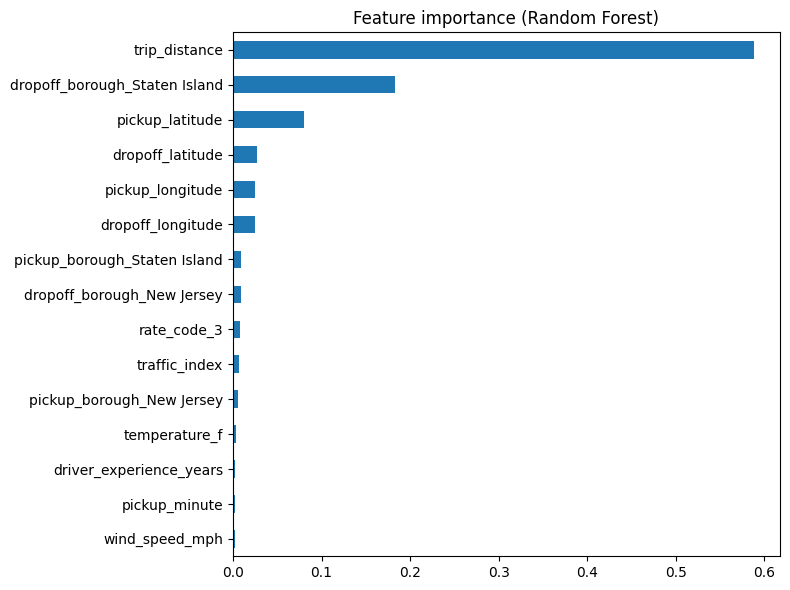

In [ ]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)
print(importance.head(15).round(4).to_string())

importance.head(15)[::-1].plot(kind='barh', figsize=(8,6))
plt.title('Feature importance (Random Forest)')
plt.tight_layout()
plt.show()

# Training curves

Watch `val_loss`, not `loss`. If `loss` falls while `val_loss` rises, that is overfitting.

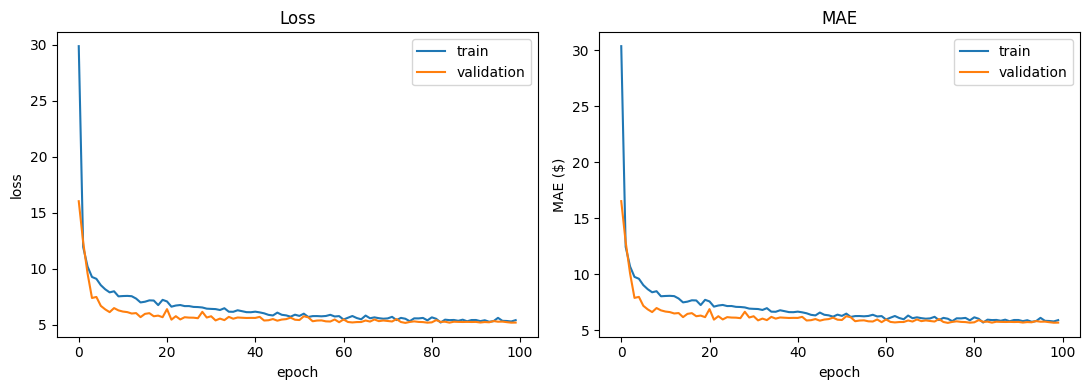

In [ ]:
plt.figure(figsize=(11,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.title('Loss'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='train')
plt.plot(history.history['val_mae'], label='validation')
plt.xlabel('epoch'); plt.ylabel('MAE ($)'); plt.title('MAE'); plt.legend()

plt.tight_layout()
plt.show()

# Actual vs Predicted / Residuals

This is the regression equivalent of a confusion matrix.

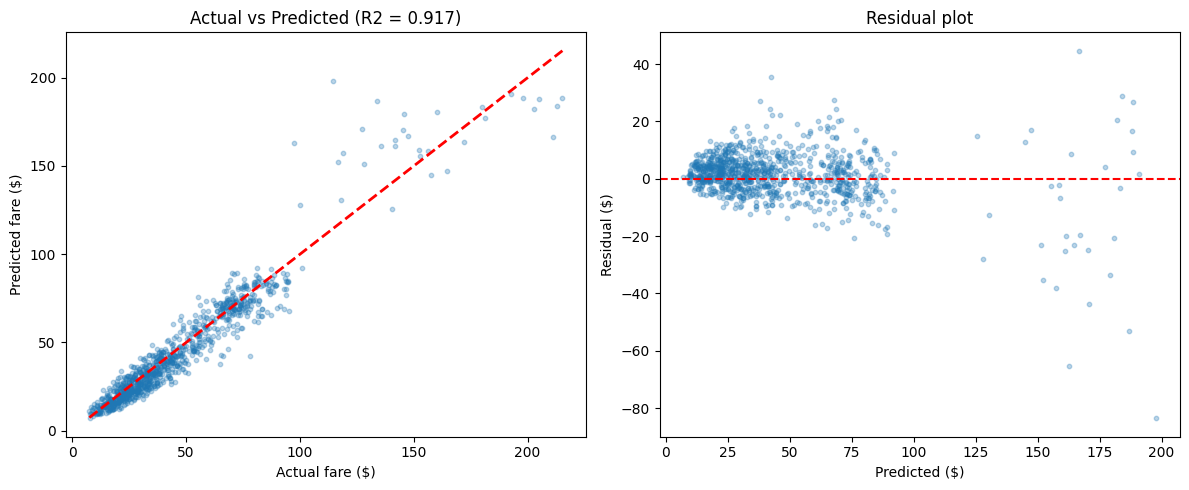

In [ ]:
y_pred = ann.predict(X_test, verbose=0).flatten()
y_true = np.asarray(y_test)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].scatter(y_true, y_pred, alpha=0.3, s=10)
lims = [y_true.min(), y_true.max()]
ax[0].plot(lims, lims, 'r--', lw=2)
ax[0].set_xlabel('Actual fare ($)')
ax[0].set_ylabel('Predicted fare ($)')
ax[0].set_title(f'Actual vs Predicted (R2 = {r2_score(y_true, y_pred):.3f})')

residual = y_true - y_pred
ax[1].scatter(y_pred, residual, alpha=0.3, s=10)
ax[1].axhline(0, color='r', ls='--')
ax[1].set_xlabel('Predicted ($)')
ax[1].set_ylabel('Residual ($)')
ax[1].set_title('Residual plot')

plt.tight_layout()
plt.show()

# Model Persistence

Save the scaler and the feature list too - without them the saved model cannot be used on new data.

In [ ]:
import joblib

ann.save('fare_model.keras')
joblib.dump(sc, 'scaler.pkl')
joblib.dump(list(X.columns), 'feature_names.pkl')
joblib.dump(encoder, 'onehot_encoder.pkl')

print("saved: fare_model.keras, scaler.pkl, feature_names.pkl, onehot_encoder.pkl")

saved: fare_model.keras, scaler.pkl, feature_names.pkl, onehot_encoder.pkl


#Conclusion

Initial models plateaued at R² ≈ 0.61. Increasing network capacity and training length produced negligible improvement (+0.024), and a Random Forest baseline performed comparably — indicating the limitation was the data rather than model capacity. Investigation of describe() revealed sentinel values (-999 in temperature_f), missing coordinates encoded as 0, transposed latitude/longitude fields, and inconsistent categorical encodings. After correcting these, the same architecture reached R² 0.921 with MAE $5.85, confirming data quality as the binding constraint.

In [ ]:
%%writefile app.py
from flask import Flask, request, jsonify
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf

app = Flask(__name__)

# Load artifacts
model = tf.keras.models.load_model('fare_model.keras')
scaler = joblib.load('scaler.pkl')
encoder = joblib.load('onehot_encoder.pkl')
feature_names = joblib.load('feature_names.pkl')

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json()

        # BUG FIX: the alignment loop below fills ANY missing training column
        # with 0. That is correct for one-hot columns, but it also means a
        # request that forgets 'trip_distance' gets trip_distance = 0 and a
        # confident, wrong fare instead of an error. Check the raw inputs first.
        REQUIRED = ['driver_experience_years', 'vendor_name', 'vehicle_type',
                    'pickup_latitude', 'pickup_longitude', 'dropoff_latitude',
                    'dropoff_longitude', 'trip_distance', 'pickup_borough',
                    'dropoff_borough', 'passenger_count', 'rate_code',
                    'payment_type', 'store_and_fwd_flag', 'weather_condition',
                    'temperature_f', 'precipitation_in', 'wind_speed_mph',
                    'traffic_index', 'is_holiday', 'pickup_month',
                    'pickup_day', 'pickup_hour', 'pickup_minute']
        missing = [c for c in REQUIRED if c not in data]
        if missing:
            return jsonify({'error': f'missing required fields: {missing}'}), 400

        df_input = pd.DataFrame([data])

        # 1. Binary Mapping
        if 'store_and_fwd_flag' in df_input.columns:
            df_input['store_and_fwd_flag'] = df_input['store_and_fwd_flag'].map({'N': 0, 'Y': 1}).fillna(0)

        # 2. One-Hot Encoding
        onehot_cols = ['vendor_name', 'payment_type', 'vehicle_type', 'weather_condition', 'pickup_borough', 'dropoff_borough', 'rate_code']
        # BUG FIX: the encoder was fitted with handle_unknown='ignore', so an
        # unseen category (e.g. 'Verifone' instead of 'VERIFONE') is encoded as
        # all zeros and the model returns a plausible but wrong number. Reject
        # it instead of guessing.
        for i, col in enumerate(onehot_cols):
            allowed = list(encoder.categories_[i])
            if df_input[col].iloc[0] not in allowed:
                return jsonify({'error': f'unknown {col}: {df_input[col].iloc[0]!r}. allowed: {allowed}'}), 400

        encoded_data = encoder.transform(df_input[onehot_cols])
        encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(onehot_cols), index=df_input.index)

        # Combine and align with training features
        df_final = pd.concat([df_input.drop(columns=onehot_cols), encoded_df], axis=1)

        # Ensure all training features exist (fill missing with 0)
        for col in feature_names:
            if col not in df_final.columns:
                df_final[col] = 0

        # Reorder columns to match scaler
        df_final = df_final[feature_names]

        # 3. Scale and Predict
        scaled_input = scaler.transform(df_final)
        prediction = model.predict(scaled_input, verbose=0)[0][0]

        return jsonify({'predicted_fare': float(prediction)})

    except Exception as e:
        return jsonify({'error': str(e)}), 400

if __name__ == '__main__':
    app.run(debug=True, port=5000)

In [ ]:
%%writefile requirements.txt
flask
pandas
numpy
joblib
scikit-learn
tensorflow

Writing requirements.txt


In [ ]:
import requests
import json

# The local URL for your Flask app
url = 'http://127.0.0.1:5000/predict'

# Sample payload matching the raw columns expected by your app.py logic
payload = {
    "driver_experience_years": 5.0,
    "vendor_name": "VTS",
    "vehicle_type": "Sedan",
    "pickup_latitude": 40.75,
    "pickup_longitude": -73.98,
    "dropoff_latitude": 40.76,
    "dropoff_longitude": -73.99,
    "trip_distance": 3.5,
    "pickup_borough": "Manhattan",
    "dropoff_borough": "Manhattan",
    "passenger_count": 1,
    "rate_code": "1",
    "payment_type": "Credit Card",
    "store_and_fwd_flag": "N",
    "weather_condition": "clear",
    "temperature_f": 65.0,
    "precipitation_in": 0.0,
    "wind_speed_mph": 5.5,
    "traffic_index": 4.2,
    "is_holiday": 0,
    "pickup_month": 10,
    "pickup_day": 25,
    "pickup_hour": 14,
    "pickup_minute": 30
}

try:
    response = requests.post(url, json=payload)
    print(f"Status Code: {response.status_code}")
    print("Response JSON:", response.json())
except Exception as e:
    print(f"Failed to connect: {e}")